# 6. Отбор и регуляризация линейных моделей.

Упражнения из **6 главы** книги [Введение в статистическое обучение](http://www-bcf.usc.edu/~gareth/ISL/) Гарета Джеймса, Даниела Уиттена, Тревора Хасти, Роберта Тибширани, Джонатана Тейлора.

## Практические задания.

### Задание 8.

В этом у пражнении мы сгенерируем искуственные данные, после чего применим к ним методы пошагового включения и исключения переменных.

(a) Воспользуйтесть методом normal() генератора случайных чисел для создания предиктора X длины n = 100, а также вектр остатков e такой же длины.

In [159]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.api import OLS
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from functools import partial
from ISLP.models import ModelSpec as MS
from ISLP.models import \
(Stepwise, 
sklearn_selected,
sklearn_selection_path)

In [160]:
!pip install l0bnb

In [161]:
from l0bnb import fit_path

In [162]:
np.random.seed(seed = 42)

In [163]:
rng = np.random.default_rng(1)
X = rng.normal(size = 100)
e = rng.normal(size = 100)

(b) Сгенерируйте вектор отлика Y длины n = 100 в сооствествии с моделью

$Y = \beta_{0} + \beta_{1}*x + \beta_{2}*x^{2} + \beta_{3}*x^{3} + e$

In [164]:
coefs = np.array([11,  8, 29, 21])

In [165]:
y = np.array([0]*100)

In [166]:
for i in range(4):
    y = y + coefs[i]*X**i

In [167]:
y

array([  18.09482227,   48.79698984,   17.56764741,    3.34911899,
         57.59719461,   22.21699932,   11.81453095,   29.56328803,
         18.78864197,   16.39634151,   11.25128698,   27.47326787,
         12.44898185,   10.37557526,   11.53044715,   30.7005389 ,
         11.36485057,   10.61544739,   12.4358558 ,   10.5034827 ,
         11.06707134,   10.55831549,  115.42379997,   69.87160297,
       -216.01845774,  -42.18404923,   10.37552878,   11.21125662,
         14.2375795 ,   14.32375231,  357.49406001,    9.08755604,
         10.98347934,  327.36732621,   33.98195355,   35.17631933,
         11.6979853 ,  -17.42106817,   13.25163229,   12.24395693,
          6.04021537,   12.37383292,   10.56631654,   11.6179893 ,
         10.47396404,   12.04653838,   11.3223613 ,   11.65792701,
         30.36922959,   56.0231724 ,   17.24576694,   12.36575863,
         40.60230941,   11.63255485,   54.7180633 ,    9.88377787,
         58.6261876 ,   10.85099648,    5.3392567 ,   10.69673

(c) Воспользуйтесь методо пошагового включения для выбора модели,  включающией предикторы $X, X^{2}, ..., X^{10}$. Какая модель будет оптимальной, согласно $C_{p}$? Приведите коэффициенты для полученной модели.

In [168]:
def nCp(sigma2, estimator, X, y):
    n, p = X.shape
    Yhat = estimator.predict(X)
    RSS = np.sum((y-Yhat)**2)
    return -(RSS + 2 * p * sigma2)/n

In [169]:
def conv_to_poly(data: pd.DataFrame(), degree: int = 2) -> pd.DataFrame():
    poly = PolynomialFeatures(degree = degree)
    X = poly.fit_transform(data)
    return pd.DataFrame(data = X, columns = ['interception'] + [f'x^{i}' for i in range(1, degree+1)])

In [170]:
X = pd.DataFrame(data = X, columns = ['x'])

In [171]:
X = conv_to_poly(X, degree = 10)

In [172]:
X

,interception,x^1,x^2,x^3,x^4,x^5,x^6,x^7,x^8,x^9,x^10
0,1.0,0.345584,0.119428,0.041273,0.014263,4.929119e-03,1.703426e-03,5.886770e-04,2.034375e-04,7.030477e-05,2.429622e-05
1,1.0,0.821618,0.675056,0.554639,0.455701,3.744123e-01,3.076239e-01,2.527494e-01,2.076635e-01,1.706201e-01,1.401846e-01
2,1.0,0.330437,0.109189,0.036080,0.011922,3.939525e-03,1.301765e-03,4.301515e-04,1.421380e-04,4.696766e-05,1.551986e-05
3,1.0,-1.303157,1.698219,-2.213046,2.883947,-3.758236e+00,4.897573e+00,-6.382308e+00,8.317150e+00,-1.083855e+01,1.412434e+01
4,1.0,0.905356,0.819669,0.742092,0.671858,6.082703e-01,5.507011e-01,4.985804e-01,4.513927e-01,4.086711e-01,3.699927e-01
...,...,...,...,...,...,...,...,...,...,...,...
95,1.0,-2.250854,5.066345,-11.403604,25.667851,-5.777459e+01,1.300422e+02,-2.927060e+02,6.588386e+02,-1.482950e+03,3.337904e+03
96,1.0,-0.138655,0.019225,-0.002666,0.000370,-5.124869e-05,7.105904e-06,-9.852714e-07,1.366131e-07,-1.894214e-08,2.626428e-09
97,1.0,0.033000,0.001089,0.000036,0.000001,3.913601e-08,1.291492e-09,4.261938e-11,1.406444e-12,4.641280e-14,1.531627e-15
98,1.0,-1.425349,2.031620,-2.895767,4.127478,-5.883097e+00,8.385466e+00,-1.195222e+01,1.703608e+01,-2.428236e+01,3.461083e+01


In [173]:
design = MS(X.columns).fit(X)

In [174]:
X  = design.fit_transform(X)

In [175]:
X = X.drop('intercept', axis = 1)

In [176]:
X

,interception,x^1,x^2,x^3,x^4,x^5,x^6,x^7,x^8,x^9,x^10
0,1.0,0.345584,0.119428,0.041273,0.014263,4.929119e-03,1.703426e-03,5.886770e-04,2.034375e-04,7.030477e-05,2.429622e-05
1,1.0,0.821618,0.675056,0.554639,0.455701,3.744123e-01,3.076239e-01,2.527494e-01,2.076635e-01,1.706201e-01,1.401846e-01
2,1.0,0.330437,0.109189,0.036080,0.011922,3.939525e-03,1.301765e-03,4.301515e-04,1.421380e-04,4.696766e-05,1.551986e-05
3,1.0,-1.303157,1.698219,-2.213046,2.883947,-3.758236e+00,4.897573e+00,-6.382308e+00,8.317150e+00,-1.083855e+01,1.412434e+01
4,1.0,0.905356,0.819669,0.742092,0.671858,6.082703e-01,5.507011e-01,4.985804e-01,4.513927e-01,4.086711e-01,3.699927e-01
...,...,...,...,...,...,...,...,...,...,...,...
95,1.0,-2.250854,5.066345,-11.403604,25.667851,-5.777459e+01,1.300422e+02,-2.927060e+02,6.588386e+02,-1.482950e+03,3.337904e+03
96,1.0,-0.138655,0.019225,-0.002666,0.000370,-5.124869e-05,7.105904e-06,-9.852714e-07,1.366131e-07,-1.894214e-08,2.626428e-09
97,1.0,0.033000,0.001089,0.000036,0.000001,3.913601e-08,1.291492e-09,4.261938e-11,1.406444e-12,4.641280e-14,1.531627e-15
98,1.0,-1.425349,2.031620,-2.895767,4.127478,-5.883097e+00,8.385466e+00,-1.195222e+01,1.703608e+01,-2.428236e+01,3.461083e+01


In [177]:
sigma2 = OLS(y, X).fit().scale

In [178]:
neg_Cp = partial(nCp, sigma2)

In [179]:
strategy = Stepwise.first_peak(design, direction='forward', max_terms=len(design.terms))

In [180]:
hitters_Cp = sklearn_selected(OLS, strategy, scoring = neg_Cp)
hitters_Cp.fit(X, y)

In [181]:
best_model = OLS(y, X[['interception']+list(hitters_Cp.selected_state_)]).fit()

In [182]:
print(best_model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 2.784e+32
Date:                Sun, 08 Dec 2024   Prob (F-statistic):               0.00
Time:                        14:31:35   Log-Likelihood:                 3015.7
No. Observations:                 100   AIC:                            -6023.
Df Residuals:                      96   BIC:                            -6013.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
interception    11.0000   2.36e-15   4.67e+15   

(d) Повторите пункт (c) с использованием метода пошагового исключения. Как ваш ответ соотностися с результатами, полученным в пункте (c)?

In [183]:
params = list(X.columns)
modelsParams = []
bestModels = []
while len(params) != 1:
    worstRSS = float('inf')
    for p in params:
        curPar = [i for i in params if i != p]
        model = OLS(y, X[curPar]).fit()
        RSS = np.sum((y - model.predict(X[curPar]))**2)
        if RSS < worstRSS:
            worstRSS = RSS
            parToDel = p
    params.remove(parToDel)
    modelsParams.append(np.copy(params))
    bestModels.append(OLS(y, X[params]).fit())

In [184]:
best_neg_Cp = float('-inf')

In [185]:
for i in range(len(bestModels)):
    cur_neg_Cp = neg_Cp(bestModels[i], X[modelsParams[i]], y)
    if cur_neg_Cp > best_neg_Cp:
        best_model  = bestModels[i]
        best_neg_Cp = cur_neg_Cp

In [186]:
best_model.params

interception    11.0
x^1              8.0
x^2             29.0
x^3             21.0
dtype: float64

(e) Теперь постройте лассо-модель на основе сгенерированнхы данных с использованием тех же предикторов $X, X^{2}, ..., X^{n}$. Воспользуйтесь метод перекрестной проверки для выбора оптимального значения $\lambda$. Постройте график ошибок перекретной проверки в зависимости от $\lambda$.

In [187]:
from sklearn.preprocessing import StandardScaler

In [188]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [189]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)

In [190]:
X_test = scaler.transform(X_test)

In [191]:
alphas = [0.001 * 10**i for i in range(10)]

In [192]:
MSE_train = []
MSE_test = []
for a in alphas:
    lasso = ElasticNet(l1_ratio = 1, alpha = a)
    scores = cross_val_score(lasso, X_train, y_train, scoring = 'neg_mean_squared_error', cv = 5)
    MSE_train.append(abs(np.mean(scores)))
    lasso.fit(X_train, y_train)
    y_test_pred = lasso.predict(X_test)
    MSE = mean_squared_error(y_test, y_test_pred)
    MSE_test.append(MSE)

Text(0, 0.5, 'MSE')

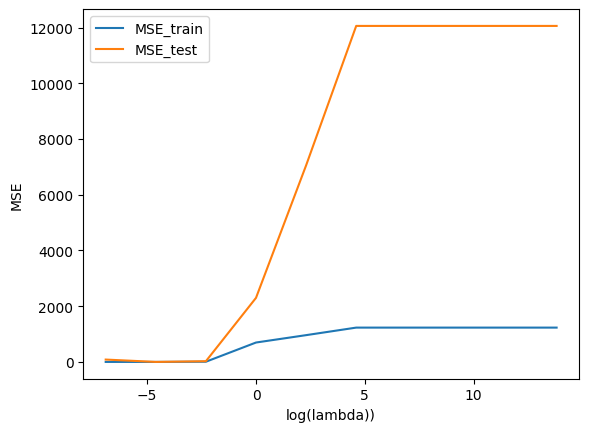

In [193]:
plt.plot(np.log(alphas), MSE_train)
plt.plot(np.log(alphas), MSE_test)
plt.legend(['MSE_train', 'MSE_test'])
plt.xlabel('log(lambda))')
plt.ylabel('MSE')

### Задание 9.

В этом упражнении мы попытаемся предсказать колвичество полученнхы заявлений от абитуриентов на основе других переменных в набое даннхы College.

(a) Рабейте набор даннхы на обучащющу и контрольную выборки.

In [194]:
college = pd.read_csv('../DataSets/College.csv')

In [195]:
college = college.drop('Unnamed: 0', axis = 1)

In [196]:
X = college.drop('Accept', axis = 1)

In [197]:
X = pd.get_dummies(X, drop_first = 'True')

In [198]:
X['Private_Yes'] = X['Private_Yes'].astype(int)

In [199]:
X

,Apps,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate,Private_Yes
0,1660,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60,1
1,2186,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56,1
2,1428,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54,1
3,417,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59,1
4,193,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
772,2197,543,4,26,3089,2029,6797,3900,500,1200,60,60,21.0,14,4469,40,0
773,1959,695,24,47,2849,1107,11520,4960,600,1250,73,75,13.3,31,9189,83,1
774,2097,695,34,61,2793,166,6900,4200,617,781,67,75,14.4,20,8323,49,1
775,10705,1317,95,99,5217,83,19840,6510,630,2115,96,96,5.8,49,40386,99,1


In [200]:
y = college['Accept']

In [201]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [202]:
X_train

,Apps,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate,Private_Yes
360,1557,397,15,40,1805,433,9813,4050,425,1000,45,63,16.7,29,7307,78,1
336,874,428,21,46,1605,246,9858,3700,450,1200,42,45,17.6,16,4796,55,1
110,81,51,33,71,139,3,8730,3600,400,800,92,92,9.3,17,10922,58,1
82,848,298,25,55,935,184,6060,3070,600,1300,62,66,17.7,13,5391,49,1
51,202,122,19,42,537,101,8540,3580,500,1400,61,80,8.8,32,8324,56,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,1465,313,71,95,1088,16,18165,6750,500,1200,100,100,12.3,49,17449,89,1
106,1013,288,55,82,943,7,11850,4270,600,900,95,99,11.4,60,13118,74,1
270,3050,471,55,86,1818,23,14360,4090,400,650,77,92,12.9,34,9605,83,1
435,776,351,22,44,1419,228,6400,3150,500,1900,58,64,16.2,8,6578,45,1


In [203]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

(b) Выполните подгонку линейно модели по методу наименьших квадратов на обучающих данных и сообщите о величине полученной ошибки на контрольной выборке.

In [204]:
linear_model = OLS(y_train, X_train).fit()

In [205]:
print(linear_model.summary())

                                 OLS Regression Results                                
Dep. Variable:                 Accept   R-squared (uncentered):                   0.596
Model:                            OLS   Adj. R-squared (uncentered):              0.583
Method:                 Least Squares   F-statistic:                              45.61
Date:                Sun, 08 Dec 2024   Prob (F-statistic):                    8.17e-92
Time:                        14:31:35   Log-Likelihood:                         -4916.7
No. Observations:                 543   AIC:                                      9867.
Df Residuals:                     526   BIC:                                      9940.
Df Model:                          17                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [206]:
y_pred = linear_model.predict(X_test)

In [207]:
def reg_model_summary(model, y_test, X_test):
    y_pred = model.predict(X_test)
    MSE = mean_squared_error(y_test, y_pred)
    RMSE = np.sqrt(MSE)
    print(f'MSE: {MSE} \nRMSE: {RMSE} \nPrecent error: {RMSE/y_train.mean()*100}')

In [208]:
reg_model_summary(linear_model, y_test, X_test)

MSE: 4218326.778499308 
RMSE: 2053.8565622991564 
Precent error: 101.59428147830975


(c) Постройте модель по методу гребневой регресси на обучающих данных с использованием значения гиперпараметра $\lambda$, выбранного с помощью метода перекрестной проверки. Сообщите о величине ошибки на контрольной выборке.

In [209]:
base_elastic_model = ElasticNet(l1_ratio=0)

In [210]:
alphas = 10**np.linspace(8, -2, 100)/y.std()

In [211]:
param_grid = {'alpha': alphas}

In [212]:
grid_model = GridSearchCV(estimator=base_elastic_model,
                          param_grid=param_grid,
                          scoring='neg_mean_squared_error',
                          cv=5,
                          verbose=2)

In [213]:
grid_model.fit(X_train, y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits
[CV] END ............................alpha=40797.77651444861; total time=   0.0s
[CV] END ............................alpha=40797.77651444861; total time=   0.0s
[CV] END ............................alpha=40797.77651444861; total time=   0.0s
[CV] END ............................alpha=40797.77651444861; total time=   0.0s
[CV] END ............................alpha=40797.77651444861; total time=   0.0s
[CV] END .............................alpha=32331.5401785656; total time=   0.0s
[CV] END .............................alpha=32331.5401785656; total time=   0.0s
[CV] END .............................alpha=32331.5401785656; total time=   0.0s
[CV] END .............................alpha=32331.5401785656; total time=   0.0s
[CV] END .............................alpha=32331.5401785656; total time=   0.0s
[CV] END ...........................alpha=25622.192668955784; total time=   0.0s
[CV] END ...........................alpha=2562

C:\Users\10\anaconda3\envs\IntToStatisctickLearnPy312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.204e+09, tolerance: 2.409e+05 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
C:\Users\10\anaconda3\envs\IntToStatisctickLearnPy312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.479e+09, tolerance: 2.958e+05 Linear regression models with null weight for the l1 regularization term are more efficiently fi

[CV] END ............................alpha=5029.740575232407; total time=   0.0s
[CV] END ............................alpha=5029.740575232407; total time=   0.0s
[CV] END ............................alpha=5029.740575232407; total time=   0.0s
[CV] END ............................alpha=3985.983389028475; total time=   0.0s
[CV] END ............................alpha=3985.983389028475; total time=   0.0s
[CV] END ............................alpha=3985.983389028475; total time=   0.0s
[CV] END ............................alpha=3985.983389028475; total time=   0.0s
[CV] END ............................alpha=3985.983389028475; total time=   0.0s
[CV] END ...........................alpha=3158.8236689278606; total time=   0.0s
[CV] END ...........................alpha=3158.8236689278606; total time=   0.0s
[CV] END ...........................alpha=3158.8236689278606; total time=   0.0s
[CV] END ...........................alpha=3158.8236689278606; total time=   0.0s
[CV] END ...................

C:\Users\10\anaconda3\envs\IntToStatisctickLearnPy312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.253e+09, tolerance: 2.521e+05 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
C:\Users\10\anaconda3\envs\IntToStatisctickLearnPy312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.195e+09, tolerance: 2.409e+05 Linear regression models with null weight for the l1 regularization term are more efficiently fi

[CV] END ............................alpha=491.4106624634001; total time=   0.0s
[CV] END ............................alpha=389.4345460710129; total time=   0.0s
[CV] END ............................alpha=389.4345460710129; total time=   0.0s
[CV] END ............................alpha=389.4345460710129; total time=   0.0s
[CV] END ............................alpha=389.4345460710129; total time=   0.0s
[CV] END ............................alpha=389.4345460710129; total time=   0.0s
[CV] END ...........................alpha=308.62021778949895; total time=   0.0s
[CV] END ...........................alpha=308.62021778949895; total time=   0.0s
[CV] END ...........................alpha=308.62021778949895; total time=   0.0s
[CV] END ...........................alpha=308.62021778949895; total time=   0.0s
[CV] END ...........................alpha=308.62021778949895; total time=   0.0s
[CV] END ...........................alpha=244.57624468443916; total time=   0.0s
[CV] END ...................

...

[CV] END .........................alpha=0.002177254625595849; total time=   0.0s
[CV] END .........................alpha=0.002177254625595849; total time=   0.0s
[CV] END ........................alpha=0.0017254370561466702; total time=   0.0s
[CV] END ........................alpha=0.0017254370561466702; total time=   0.0s
[CV] END ........................alpha=0.0017254370561466702; total time=   0.0s
[CV] END ........................alpha=0.0017254370561466702; total time=   0.0s
[CV] END ........................alpha=0.0017254370561466702; total time=   0.0s
[CV] END ........................alpha=0.0013673793591823635; total time=   0.0s
[CV] END ........................alpha=0.0013673793591823635; total time=   0.0s
[CV] END ........................alpha=0.0013673793591823635; total time=   0.0s
[CV] END ........................alpha=0.0013673793591823635; total time=   0.0s
[CV] END ........................alpha=0.0013673793591823635; total time=   0.0s
[CV] END ...................

C:\Users\10\anaconda3\envs\IntToStatisctickLearnPy312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.839e+07, tolerance: 3.226e+05 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
C:\Users\10\anaconda3\envs\IntToStatisctickLearnPy312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.143e+07, tolerance: 2.521e+05 Linear regression models with null weight for the l1 regularization term are more efficiently fi

[CV] END .......................alpha=0.00016857691845483585; total time=   0.0s
[CV] END .......................alpha=0.00016857691845483585; total time=   0.0s
[CV] END .......................alpha=0.00013359432493266049; total time=   0.0s
[CV] END .......................alpha=0.00013359432493266049; total time=   0.0s
[CV] END .......................alpha=0.00013359432493266049; total time=   0.0s
[CV] END .......................alpha=0.00013359432493266049; total time=   0.0s
[CV] END .......................alpha=0.00013359432493266049; total time=   0.0s
[CV] END ........................alpha=0.0001058712178262695; total time=   0.0s
[CV] END ........................alpha=0.0001058712178262695; total time=   0.0s
[CV] END ........................alpha=0.0001058712178262695; total time=   0.0s
[CV] END ........................alpha=0.0001058712178262695; total time=   0.0s
[CV] END ........................alpha=0.0001058712178262695; total time=   0.0s
[CV] END ...................

C:\Users\10\anaconda3\envs\IntToStatisctickLearnPy312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.053e+07, tolerance: 2.409e+05 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
C:\Users\10\anaconda3\envs\IntToStatisctickLearnPy312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.775e+07, tolerance: 2.958e+05 Linear regression models with null weight for the l1 regularization term are more efficiently fi

GridSearchCV(cv=5, estimator=ElasticNet(l1_ratio=0),
             param_grid={'alpha': array([4.07977765e+04, 3.23315402e+04, 2.56221927e+04, 2.03051495e+04,
       1.60914837e+04, 1.27522257e+04, 1.01059208e+04, 8.00876937e+03,
       6.34681276e+03, 5.02974058e+03, 3.98598339e+03, 3.15882367e+03,
       2.50331374e+03, 1.98383333e+03, 1.57215398e+03, 1.24590515e+03,
       9.87358521e+02, 7.82464742e+02, 6....
       8.58754089e-04, 6.80547929e-04, 5.39322595e-04, 4.27403934e-04,
       3.38710308e-04, 2.68422127e-04, 2.12719945e-04, 1.68576918e-04,
       1.33594325e-04, 1.05871218e-04, 8.39011296e-05, 6.64902103e-05,
       5.26923546e-05, 4.17577899e-05, 3.30923344e-05, 2.62251090e-05,
       2.07829504e-05, 1.64701328e-05, 1.30522986e-05, 1.03437234e-05,
       8.19722390e-06, 6.49615976e-06, 5.14809551e-06, 4.07977765e-06])},
             scoring='neg_mean_squared_error', verbose=2)

In [214]:
grid_model.best_estimator_

ElasticNet(alpha=4.0797776514448615e-06, l1_ratio=0)

In [215]:
reg_model_summary(grid_model,y_test, X_test)

MSE: 549981.9543257529 
RMSE: 741.6076822186734 
Precent error: 36.683720273756215


(d) Постройте модель по методу лассо регресси на обучающих данных с использованием значения гиперпараметра $\lambda$, выбранного с помощью метода перекрестной проверки. Сообщите о величине ошибки на контрольной выборке.

In [216]:
base_elastic_model = ElasticNet(l1_ratio=1)

In [217]:
alphas = 10**np.linspace(8, -2, 100)/y.std()

In [218]:
param_grid = {'alpha': alphas}

In [219]:
grid_model = GridSearchCV(estimator=base_elastic_model,
                          param_grid=param_grid,
                          scoring='neg_mean_squared_error',
                          cv=5,
                          verbose=2)

In [220]:
grid_model.fit(X_train, y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits
[CV] END ............................alpha=40797.77651444861; total time=   0.0s
[CV] END ............................alpha=40797.77651444861; total time=   0.0s
[CV] END ............................alpha=40797.77651444861; total time=   0.0s
[CV] END ............................alpha=40797.77651444861; total time=   0.0s
[CV] END ............................alpha=40797.77651444861; total time=   0.0s
[CV] END .............................alpha=32331.5401785656; total time=   0.0s
[CV] END .............................alpha=32331.5401785656; total time=   0.0s
[CV] END .............................alpha=32331.5401785656; total time=   0.0s
[CV] END .............................alpha=32331.5401785656; total time=   0.0s
[CV] END .............................alpha=32331.5401785656; total time=   0.0s
[CV] END ...........................alpha=25622.192668955784; total time=   0.0s
[CV] END ...........................alpha=2562

GridSearchCV(cv=5, estimator=ElasticNet(l1_ratio=1),
             param_grid={'alpha': array([4.07977765e+04, 3.23315402e+04, 2.56221927e+04, 2.03051495e+04,
       1.60914837e+04, 1.27522257e+04, 1.01059208e+04, 8.00876937e+03,
       6.34681276e+03, 5.02974058e+03, 3.98598339e+03, 3.15882367e+03,
       2.50331374e+03, 1.98383333e+03, 1.57215398e+03, 1.24590515e+03,
       9.87358521e+02, 7.82464742e+02, 6....
       8.58754089e-04, 6.80547929e-04, 5.39322595e-04, 4.27403934e-04,
       3.38710308e-04, 2.68422127e-04, 2.12719945e-04, 1.68576918e-04,
       1.33594325e-04, 1.05871218e-04, 8.39011296e-05, 6.64902103e-05,
       5.26923546e-05, 4.17577899e-05, 3.30923344e-05, 2.62251090e-05,
       2.07829504e-05, 1.64701328e-05, 1.30522986e-05, 1.03437234e-05,
       8.19722390e-06, 6.49615976e-06, 5.14809551e-06, 4.07977765e-06])},
             scoring='neg_mean_squared_error', verbose=2)

In [221]:
grid_model.best_estimator_

ElasticNet(alpha=3.7173414492288748, l1_ratio=1)

In [222]:
reg_model_summary(grid_model,y_test, X_test)

MSE: 557882.5320628528 
RMSE: 746.9153446427866 
Precent error: 36.946264484586386


(e) Постройте модель по методу PCR на обучающих даннхы с использованием значения M, выбранного с помощью метода перекрестной проверки.

In [230]:
pca = PCA()
linreg = LinearRegression()

In [231]:
pipe = Pipeline([('pca', pca),
                ('linreg', linreg)])

In [232]:
param_grid = {'pca__n_components': range(1, 20)}
grid = GridSearchCV(pipe, param_grid, cv = 5, scoring = 'neg_mean_squared_error')
grid.fit(X_train, y_train)

C:\Users\10\anaconda3\envs\IntToStatisctickLearnPy312\Lib\site-packages\sklearn\model_selection\_validation.py:540: FitFailedWarning: 
10 fits failed out of a total of 95.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\10\anaconda3\envs\IntToStatisctickLearnPy312\Lib\site-packages\sklearn\model_selection\_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\10\anaconda3\envs\IntToStatisctickLearnPy312\Lib\site-packages\sklearn\base.py", line 1473, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\10\anaconda3\env

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('pca', PCA()),
                                       ('linreg', LinearRegression())]),
             param_grid={'pca__n_components': range(1, 20)},
             scoring='neg_mean_squared_error')

In [233]:
grid.best_estimator_

Pipeline(steps=[('pca', PCA(n_components=17)), ('linreg', LinearRegression())])

In [234]:
reg_model_summary(grid, y_test, X_test)

MSE: 549981.7756901494 
RMSE: 741.6075617805885 
Precent error: 36.68371431627071


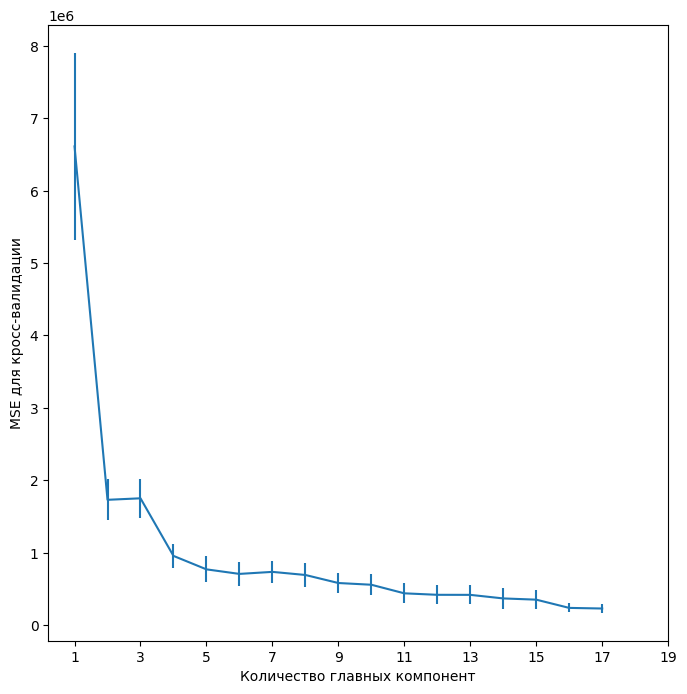

In [248]:
pcr_fig, ax = plt.subplots(figsize = (8,8))
n_comp = param_grid['pca__n_components']
ax.errorbar(n_comp, 
            -grid.cv_results_['mean_test_score'], 
           grid.cv_results_['std_test_score']/np.sqrt(5))
ax.set_ylabel('MSE для кросс-валидации')
ax.set_xlabel('Количество главных компонент')
ax.set_xticks(n_comp[::2])

(f) Постройте модель по методу PCR на обучающих даннхы с использованием значения M, выбранного с помощью метода перекрестной проверки.

In [249]:
from sklearn.cross_decomposition import PLSRegression

In [250]:
pls = PLSRegression()

In [258]:
param_grid = {'n_components': range(1, 20)}
grid = GridSearchCV(pls, param_grid, cv = 5, scoring = 'neg_mean_squared_error')
grid.fit(X_train, y_train)

C:\Users\10\anaconda3\envs\IntToStatisctickLearnPy312\Lib\site-packages\sklearn\model_selection\_validation.py:540: FitFailedWarning: 
10 fits failed out of a total of 95.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\10\anaconda3\envs\IntToStatisctickLearnPy312\Lib\site-packages\sklearn\model_selection\_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\10\anaconda3\envs\IntToStatisctickLearnPy312\Lib\site-packages\sklearn\cross_decomposition\_pls.py", line 713, in fit
    super().fit(X, y)
  File "C:\Users\10\anaconda3\envs\IntToStatisctickLearnPy312\Lib\site-packages\sklearn\base.py"

GridSearchCV(cv=5, estimator=PLSRegression(),
             param_grid={'n_components': range(1, 20)},
             scoring='neg_mean_squared_error')

In [259]:
grid.best_estimator_

PLSRegression(n_components=9)

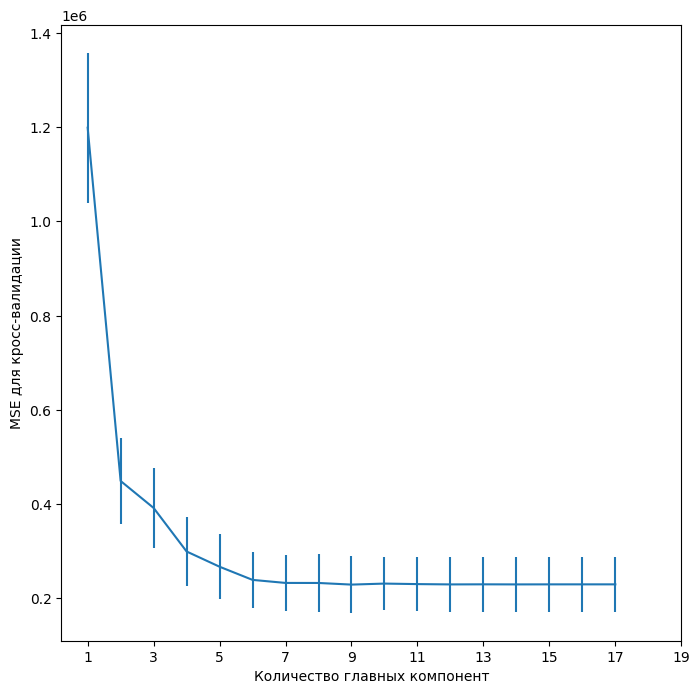

In [261]:
pcs_fig, ax = plt.subplots(figsize = (8,8))
n_comp = param_grid['n_components']
ax.errorbar(n_comp, 
            -grid.cv_results_['mean_test_score'], 
           grid.cv_results_['std_test_score']/np.sqrt(5))
ax.set_ylabel('MSE для кросс-валидации')
ax.set_xlabel('Количество главных компонент')
ax.set_xticks(n_comp[::2])

In [262]:
reg_model_summary(grid, y_test, X_test)

MSE: 547012.5111938348 
RMSE: 739.602941580031 
Precent error: 36.584555517817634
